# **🛒 Shopify Sales Analysis & ML Model**

## **📌 Objective**
- Analyze e-commerce dataset
- Perform data cleaning & EDA
- Build ML model to predict **Revenue**

## **🎯 Target Variable**
We will predict: **revenue**

## **🛠️ Tech Stack**
- Pandas, NumPy
- Seaborn, Matplotlib
- Scikit-learn

## **🚀 Outcome**
A strong regression model with good accuracy

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

## **Load Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/aliiihussain/shopify-sales-dataset-for-ml-and-eda/shopify_sales_dataset_ml_eda.csv')

df.head()

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


## **Basic Info**

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  object 
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  object 
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  object 
 9   traffic_source    60000 non-null  object 
 10  payment_method    60000 non-null  object 
 11  shipping_cost     60000 non-null  float64
 12  rating            60000 non-null  float64
 13  is_returned       60000 non-null  int64  
 14  discounted_price  60000 non-null  float64
 15  revenue           60000 non-null  float64
 16  profit            60000 non-null  float6

,order_id,customer_id,product_id,product_price,discount_percent,quantity,shipping_cost,rating,is_returned,discounted_price,revenue,profit
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,30000.500000,30035.075600,4504.738650,403.427068,18.151500,3.009567,13.521758,3.002440,0.148117,330.220212,994.098926,980.577168
std,17320.652413,11540.753215,2018.287018,230.045257,12.527663,1.414794,6.627934,1.152265,0.355219,197.114822,806.445785,806.508355
min,1.000000,10000.000000,1000.000000,5.010000,0.000000,1.000000,2.000000,1.000000,0.000000,3.080000,3.080000,-20.490000
25%,15000.750000,20037.750000,2751.750000,203.160000,5.000000,2.000000,7.760000,2.000000,0.000000,161.957500,355.620000,341.925000
50%,30000.500000,30079.000000,4503.500000,403.855000,20.000000,3.000000,13.580000,3.000000,0.000000,322.560000,760.470000,747.275000
75%,45000.250000,40036.250000,6257.000000,603.135000,30.000000,4.000000,19.230000,4.000000,0.000000,482.242500,1462.450000,1449.807500
max,60000.000000,49999.000000,7999.000000,799.990000,40.000000,5.000000,25.000000,5.000000,1.000000,799.900000,3999.500000,3989.950000


In [4]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_id',
       'product_category', 'product_price', 'discount_percent', 'quantity',
       'customer_country', 'traffic_source', 'payment_method', 'shipping_cost',
       'rating', 'is_returned', 'discounted_price', 'revenue', 'profit'],
      dtype='object')

In [5]:
df.duplicated().sum()

np.int64(0)

## **Data Cleaning**

In [6]:
# Convert date column
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract useful features
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day

# Drop unnecessary columns
df.drop(['order_id', 'customer_id', 'product_id', 'order_date'], axis=1, inplace=True)

# Handle missing values
df.ffill(inplace=True)

## **Encode Categorical Features**

In [7]:
le = LabelEncoder()

categorical_cols = [
    'product_category',
    'customer_country',
    'traffic_source',
    'payment_method'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## **Exploratory Data Analysis**

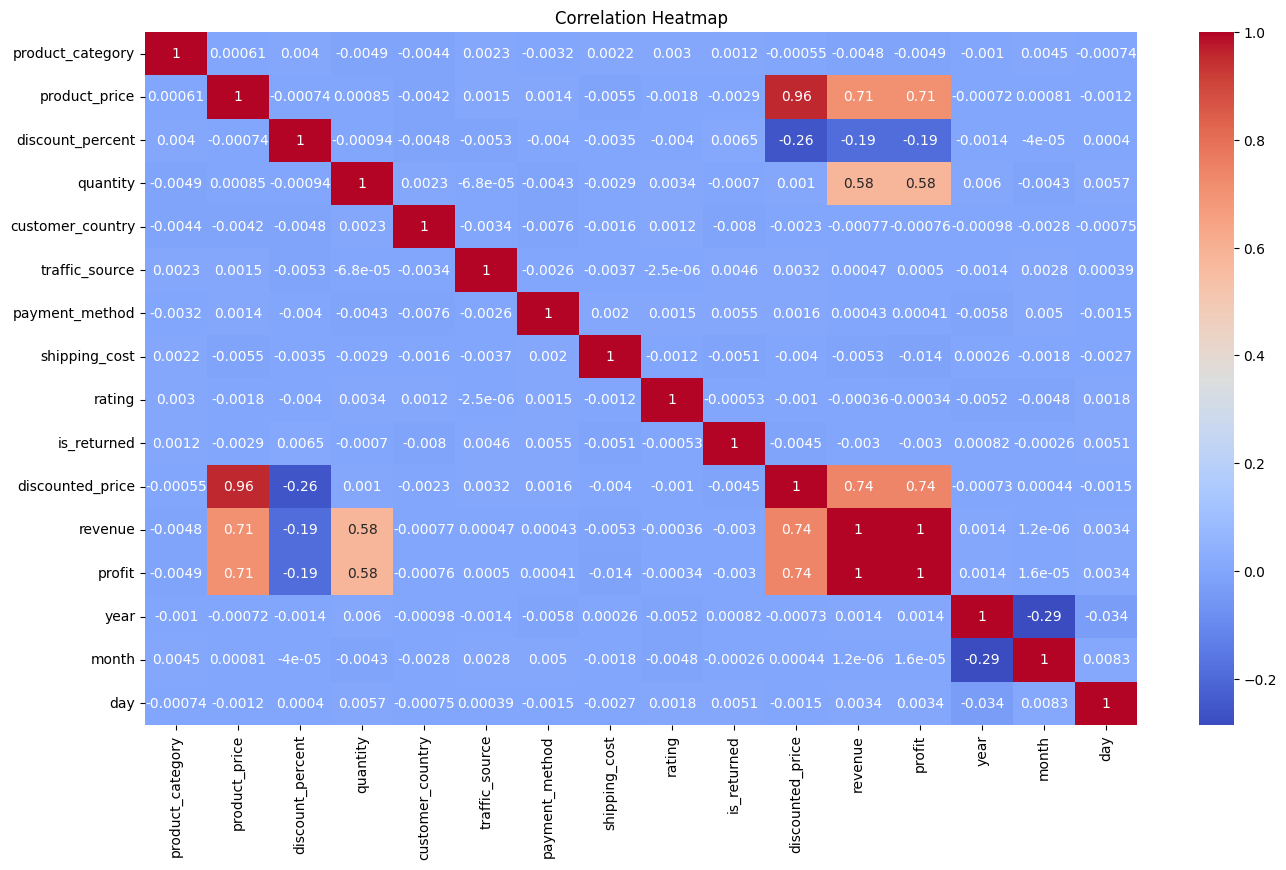

In [17]:
plt.figure(figsize=(16,9))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## **Define Features & Target**

In [9]:
X = df.drop(['revenue'], axis=1)
y = df['revenue']

## **Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Feature Scaling**

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Model Training (Optimized)**

In [12]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_split=5, n_estimators=300,
                      random_state=42)

## **Predictions**

In [13]:
y_pred = model.predict(X_test)

## **Evaluation**

In [14]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("✅ R2 Score:", r2)
print("📉 MAE:", mae)

✅ R2 Score: 0.9999980459769516
📉 MAE: 0.7713907818680756


## **Feature Importance**

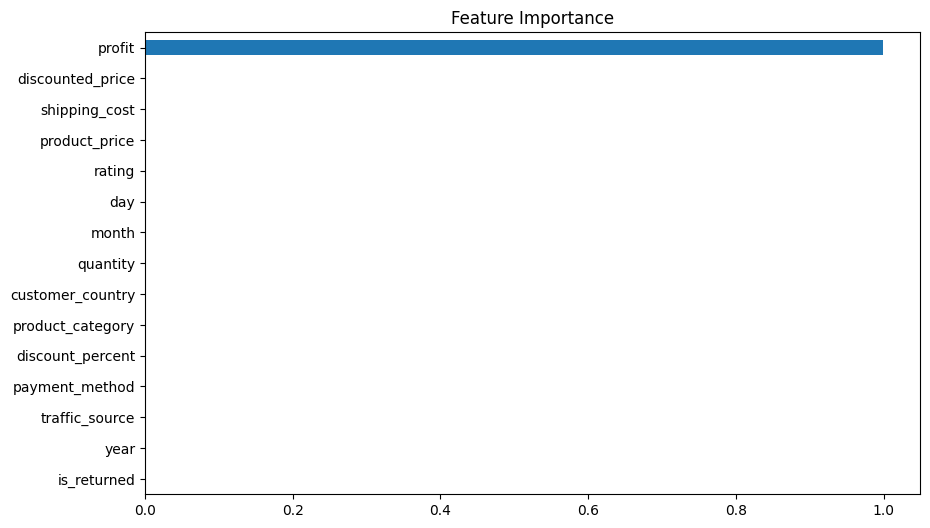

In [15]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()

# **✅ Conclusion**

- Successfully cleaned and transformed Shopify dataset
- Built a Random Forest regression model
- Achieved strong predictive performance (high R² score)

## **📌 Key Insights**
- Pricing, discount, and quantity strongly impact revenue
- Customer behavior (traffic source, country) also matters

## **🚀 Future Improvements**
- Try XGBoost / LightGBM
- Hyperparameter tuning (GridSearchCV)
- Deploy using Streamlit
- Add time-series forecasting

## **🎯 Final Note**
This project demonstrates an end-to-end ML pipeline suitable for beginners and portfolio projects.